In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
df=pd.read_csv("sales_data.csv")
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


## Load, clean, explore dataset

In [37]:
df.isnull().sum()

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
print(df["Product"].unique()) ## uniqiue products from the data
print(df["Region"].unique())

['Phone' 'Headphones' 'Laptop' 'Tablet' 'Monitor']
['East' 'North' 'West' 'South']


In [40]:
sales=df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)
sales

Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64

In [30]:
region_sales=data.groupby("Region")["Total_Sales"].sum().sort_values(ascending=False)
region_sales

Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64

### Calculate metrics, find patterns

In [43]:

import pandas as pd



# Ensure Date is in datetime format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# --- Metrics ---

# 1. Total revenue per product
sales_by_product = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)
print (sales_by_product)

# 2. Total revenue per region
sales_by_region = df.groupby("Region")["Total_Sales"].sum().sort_values(ascending=False)
print("\nTotal Revenue by Region:\n", sales_by_region)

# 3. Overall Average Order Value (AOV)
overall_aov = df["Total_Sales"].sum() / df["Quantity"].sum()
print("\nOverall Average Order Value (AOV):", round(overall_aov, 2))

# 4. Top 5 customers by sales
top_customers = df.groupby("Customer_ID")["Total_Sales"].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Customers by Sales:\n", top_customers)


Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64

Total Revenue by Region:
 Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64

Overall Average Order Value (AOV): 25868.3

Top 5 Customers by Sales:
 Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
Name: Total_Sales, dtype: int64


In [42]:

# --- Patterns ---

# 5. Best-selling product
top_product = sales_by_product.idxmax()
print("\nTop-Selling Product:", top_product)

# 6. Highest revenue region
top_region = sales_by_region.idxmax()
print("Top Region by Sales:", top_region)

# 7. Monthly sales trend
df["Month"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Total_Sales"].sum()
print("\nMonthly Sales Trend:\n", monthly_sales)

# 8. Price vs Quantity relationship (correlation)
correlation = df["Price"].corr(df["Quantity"])
print("\nCorrelation between Price and Quantity:", round(correlation, 2))

# 9. Product performance by region
product_region_sales = df.groupby(["Region", "Product"])["Total_Sales"].sum().unstack().fillna(0)
print("\nProduct Performance by Region:\n", product_region_sales)


Top-Selling Product: Laptop
Top Region by Sales: North

Monthly Sales Trend:
 Month
2024-01    4120524
2024-02    2656050
2024-03    4485006
2024-04    1103468
Freq: M, Name: Total_Sales, dtype: int64

Correlation between Price and Quantity: 0.01

Product Performance by Region:
 Product  Headphones   Laptop  Monitor    Phone   Tablet
Region                                                 
East         288361   221946   642870   506828   859634
North        107091  1798206   397100   489284  1191954
South        512168  1373120    39924  1471428   341212
West         476413   495938   268177   391854   491540


###  Make charts with matplotlib

In [46]:
import seaborn as sns

C:\Users\sreen\AppData\Local\Temp\ipykernel_2676\3288188410.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_product.index, y=sales_by_product.values, palette="viridis")


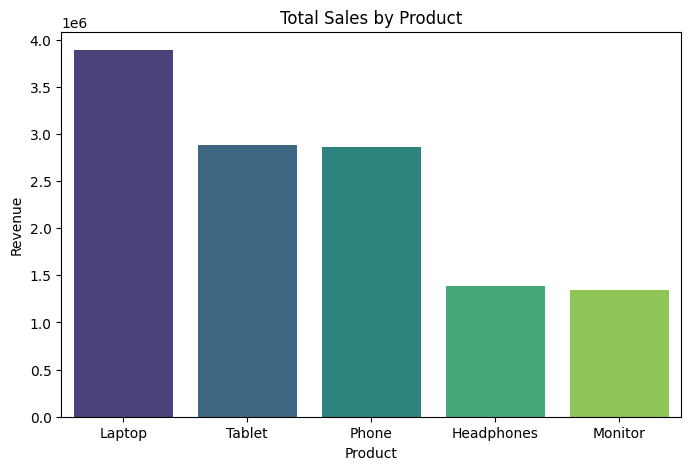

In [49]:
sales_by_product = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_product.index, y=sales_by_product.values, palette="viridis")
plt.title("Total Sales by Product")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.show()


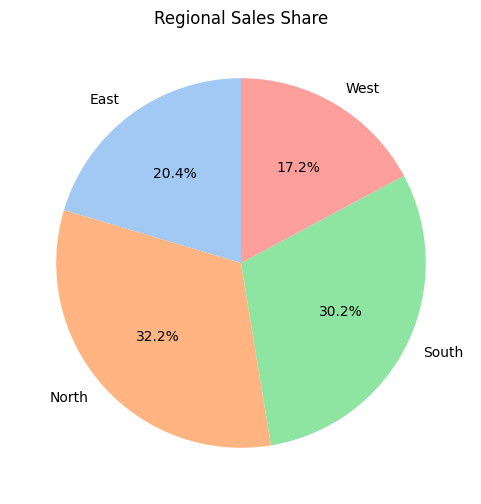

In [50]:
# --- 2. Pie Chart: Regional Sales Share ---
sales_by_region = df.groupby("Region")["Total_Sales"].sum()
plt.figure(figsize=(6,6))
plt.pie(sales_by_region, labels=sales_by_region.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Regional Sales Share")
plt.show()


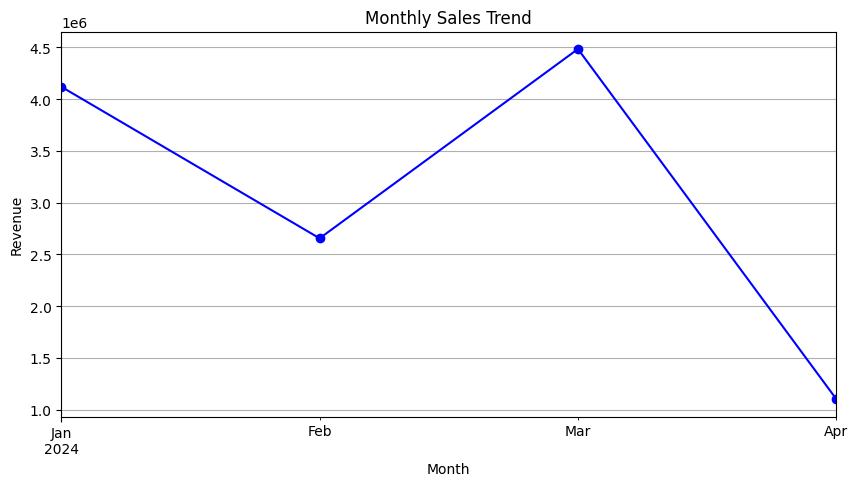

In [51]:
##  line cgatotal sales by month --
monthly_sales = df.groupby("Month")["Total_Sales"].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o", color="blue")
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.grid(True)
plt.show()


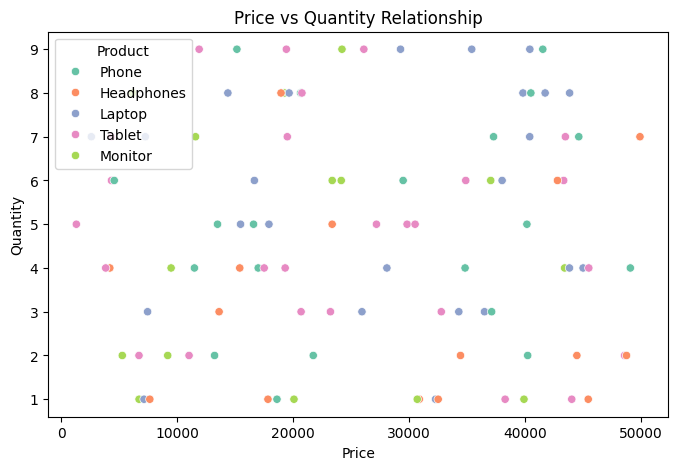

In [53]:
## sactterplot price vs quality relationshop
plt.figure(figsize=(8,5))
sns.scatterplot(x="Price", y="Quantity", data=df, hue="Product", palette="Set2")
plt.title("Price vs Quantity Relationship")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.show()


### - Combine analysis and visuals, write insights

Introduction
- Purpose: Analyze sales dataset to identify product performance, regional contributions, customer trends, and overall business insights.
- Data: Transactions from Jan–Apr 2024, across multiple products (Phones, Laptops, Tablets, Monitors, Headphones) and regions (North, South, East, West).

2. Data Overview
- Rows: 100+ transactions
- Columns: Date, Product, Quantity, Price, Customer_ID, Region, Total_Sales
- Cleaning: Converted dates, removed duplicates, checked missing values (none significant).

3. Analysis & Visuals
🔹 Sales by Product
 Bar chart already created in Day 5


Insight:
- Laptops and Tablets dominate revenue.
- Phones are strong but slightly behind laptops in total contribution.

🔹 Regional Sales Share
 Pie chart from Day 5


Insight:
- North & South regions contribute the majority of revenue.
- East and West regions are smaller but still significant.

🔹 Monthly Sales Trend
Line chart from Day 5


Insight:
- Sales show steady growth from January to March.
- April continues strong, suggesting consistent demand.
- No major seasonal dips detected in this period.

🔹 Price vs Quantity
 Scatter plot from Day 5


Insight:
- Weak correlation between price and quantity (customers buy across price ranges).
- High-value items like laptops still sell in good quantities.

🔹 Top Customers
- Top 5 customers contribute disproportionately to revenue.
- Indicates potential for loyalty programs or targeted marketing.

4. Key Findings
- Product Leader: Laptops are the top revenue driver.
- Regional Leader: North region contributes the most sales.
- Customer Insight: A few customers account for large revenue chunks.
- Trend: Sales are stable and growing month by month.
- Behavior: Price does not strongly deter quantity purchased.

5. Conclusion
- Business should focus on laptops and tablets as core revenue drivers.
- North & South regions deserve priority in marketing and distribution.
- Customer retention strategies (discounts, loyalty programs) could maximize revenue from top buyers.
- Continuous monitoring of monthly trends will help detect seasonality or shifts in demand.


